## Quenching

In [23]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, Column, vstack, hstack
from astropy.wcs import WCS
from astropy.io import ascii
from astropy.coordinates import SkyCoord
import astropy.units as u

import kuaizi
kuaizi.set_env(project='SALAD', name='', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=16, figsize=(7, 5), dpi=100)

sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/SALAD/data/')
from display import show_image_wcs
from catalog import SatCandidate

import pandas as pd
import json
from hosts_config import all_hosts

from format_sat_table import generate_latex_table_entries, format_sbf_distance, create_full_latex_table

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


    The `M_g` in the json files are incorrect!  Don't use it!!

In [24]:
def sort_by_status(table):
    status_order = {'Confirmed': 0, 'Rejected': 1, 'Unconfirmed': 2, 'Not Observed': 3}
    if 'status' in table.colnames:
        sort_key = [status_order.get(s, 3) if isinstance(s, str) else 3 
                    for s in table['status']]
    else:
        return table  # Can't sort if no status column
    sorted_indices = np.argsort(sort_key)
    sorted_table = table[sorted_indices]
    return sorted_table

In [25]:
import importlib
import hosts_config

importlib.reload(hosts_config)
from display import completeness_plot
from hosts_config import all_hosts
from paper2_hosts_list import gmos_hosts, lit_hosts, hscla_hosts, imacs_hosts

## Satellite color

In [26]:
########## Load ELVES catalog ##########
import pandas as pd
elves_sat_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SALAD/ELVES/elves_sats.txt', format='cds')
elves_sat_cat = elves_sat_cat[elves_sat_cat['Psat'] == 1.0]

elves_host_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SALAD/ELVES/elves_hosts.csv')

# Get host masses for each ELVES sat
host_masses = []
for sat in elves_sat_cat:
    host_masses.append(
        elves_host_cat[(elves_host_cat['Name'] == sat['Host'])]['$\\mathrm{log}({M}_{\\star }/{M}_{\\odot })$'][0])
elves_sat_cat['host_mass'] = host_masses

host_nsats = []
for host in elves_host_cat['Name']:
    # host_nsats.append(np.sum((elves_sat_cat['Host'] == host)))
    host_nsats.append(np.sum((elves_sat_cat['Host'] == host) & (elves_sat_cat['Rproj'] < elves_host_cat['Rvir'][elves_host_cat['Name'] == host])))
elves_host_cat['nsat'] = host_nsats
elves_maybes = elves_sat_cat[elves_sat_cat['Confirmed'] == 'False']
elves_sat_cat = elves_sat_cat[(elves_sat_cat['Host'] != 'MW') & (elves_sat_cat['Host'] != 'M31')]

gi = elves_sat_cat['gmag'] - elves_sat_cat['rimag']
gi[elves_sat_cat['Filt'] == 'gr'] = 1.53 * (gi[elves_sat_cat['Filt'] == 'gr']) - 0.032

In [27]:
(np.pi * np.rad2deg(elves_host_cat['r _cover'] / elves_host_cat['Dist'] / 1e3)**2).sum()

np.float64(inf)

In [28]:
# temp = master_cat[master_cat['status'] == 'Confirmed']
# temp['M_V'] = temp['m_V_sersic'] - (5 * np.log10(temp['host_dist']) + 25)
# temp['gi_sersic'][temp['gi_sersic'].mask] = 1.53 * temp['gr_sersic'][temp['gi_sersic'].mask] - 0.032

In [29]:
def Mv2Mstar(Mv):
    # Convert M_V to stellar mass
    # This is from Kravtsov's paper, without considering M/L -- color relation
    Lv = 10**(-0.4 * (Mv - 4.81))
    return np.log10((2.85 + 0.1 * Mv) * Lv)

Mv2Mstar(-12)

np.float64(6.941483944213906)

In [30]:
def read_catalog(file):
    cat = Table.read(file)
    for col in cat.colnames:
        if cat[col].dtype.kind == "S":
            cat[col] = cat[col].astype(str)
    return cat

master_cat = read_catalog('/scratch/gpfs/JENNYG/jiaxuanl/Data/SALAD/ELVES-Dwarf_master_cat_260812.fits')
master_cat = master_cat[master_cat['host'] != 'M33']

host_cat = read_catalog('/scratch/gpfs/JENNYG/jiaxuanl/Data/SALAD/ELVES-Dwarf_host_cat_260812.fits')
host_cat.sort('log_mstar_msun')
print('Total area:', host_cat['area_deg2'].sum(), 'deg2')

hosts = host_cat['name']
print('Total # of hosts:', len(hosts))
print('Total # of cands:', len(master_cat[master_cat['host'] != 'M33']))
print('Total # of non-SBF dists:', len(master_cat[master_cat['dist_method'] != 'SBF']))

master_cat['host_mstar'] = np.zeros(len(master_cat))
master_cat['isolated'] = np.zeros(len(master_cat), dtype=bool)

for obj in master_cat:
    host_ms = host_cat[host_cat['name'] == obj['host']]['log_mstar_msun'][0]
    obj['host_mstar'] = host_ms
    obj['isolated'] = host_cat[host_cat['name'] == obj['host']]['isolated'][0]

Total area: 155.257 deg2
Total # of hosts: 39
Total # of cands: 207
Total # of non-SBF dists: 23


In [92]:
np.sum(master_cat['Psat'] == 1)

np.int64(39)

In [94]:
(master_cat['Psat'] / master_cat['completeness']).sum()

np.float64(58.327354036285776)

In [31]:
temp = master_cat[master_cat['status'] == 'Confirmed']
temp['M_V'] = temp['m_V_sersic'] - (5 * np.log10(temp['host_dist']) + 25)
temp['gr_sersic'][temp['name'] == 'SMC'] = -999.0
temp['gi_sersic'][temp['gi_sersic'].mask] = 1.53 * temp['gr_sersic'][temp['gi_sersic'].mask] - 0.032

In [32]:
sf_names = ['SMC', "NGC4190", "NGC4163", "KK65", "dw0741p4005", 
      "UGCA319", 'dw1305m1715', "LEDA1242", "dw0017m2342", 
      "dw0017m2342", "KK16", 'KK17', 'dw0605m3325', 'AGC731457', 
      'LEDA104868', 'dw1250m1045', 'KK27', #kk27 has blue center
      'UGC07950', 'dw1250p5056', 'dw1008p7038b'
     ]

In [33]:
# temp['name'].data

In [34]:
(master_cat['Psat'] / master_cat['completeness']).sum()

np.float64(58.327354036285776)

In [35]:
(master_cat['Psat']).sum()

np.float64(56.26397920520945)

In [36]:
temp = temp[~np.isin(temp['host'], lit_hosts)]
# temp = temp[temp['M_V'] < -9]

In [37]:
# temp = temp[temp['host_mstar'] < 9] # low-mass hosts

In [18]:
# temp = temp[temp['log_m_star'] > 7]

In [38]:
kuaizi.set_matplotlib(style='JL', usetex=True, figsize=(7, 5), dpi=100, fontsize=16)

In [39]:
len(temp)

27

In [40]:
len(np.unique(temp['host']))

15

LTG: SMC
ETG: Antlia
ETG: SculptorC


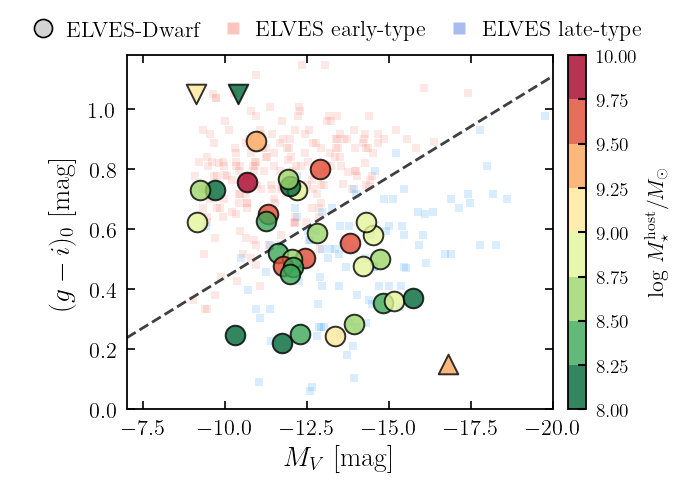

In [22]:
fig, ax = plt.subplots(figsize=(6.7, 4.6))
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D


etg = elves_sat_cat['ETG'] == 'True'
ax.scatter(elves_sat_cat['MVmag'][etg], gi[etg], c='salmon', marker='s', s=30, alpha=0.18, lw=0, zorder=1)
ax.scatter(elves_sat_cat['MVmag'][~etg], gi[~etg], c='dodgerblue', marker='s', s=30, alpha=0.16, lw=0, zorder=1)

_x = np.linspace(-7, -20, 100)
ax.plot(_x, -0.067 * _x - 0.23, ls='--', c='0.25', lw=2, zorder=2)

bounds = np.arange(8, 10.01, 0.25)
cmap = plt.get_cmap('RdYlGn_r', len(bounds) - 1)
# cmap = plt.get_cmap('PuOr_r', len(bounds) - 1)
norm = BoundaryNorm(bounds, cmap.N)

for obj in temp:
    ls = '-' if obj['isolated'] else '--'
    ls = '-'
    sc = ax.scatter(obj['M_V'], obj['gi_sersic'], c=obj['host_mstar'], cmap=cmap, norm=norm,
                    s=200, ec='k', marker='o', lw=1.4, ls=ls, alpha=0.8, zorder=5)

ltg_flag = temp['gr_sersic'] == -999.0
for obj in temp[ltg_flag]:
    print("LTG:", obj['name'])
    sc = ax.scatter(obj['M_V'], 0.15, c=obj['host_mstar'], cmap=cmap, norm=norm,
                    s=200, ec='k', marker='^', lw=1.4, alpha=0.8, zorder=5)

etg_flag = temp['gr_sersic'] == 999.0
for obj in temp[etg_flag]:
    print("ETG:", obj['name'])
    sc = ax.scatter(obj['M_V'], 1.05, c=obj['host_mstar'], cmap=cmap, norm=norm,
                    s=200, ec='k', marker='v', lw=1.4, alpha=0.8, zorder=5)


cbar = fig.colorbar(sc, ax=ax, boundaries=bounds, ticks=bounds, 
                    spacing='proportional', pad=0.03)
cbar.set_label(r'$\log\,M_{\star}^{\rm host}/M_\odot$', fontsize=16)
cbar.ax.tick_params(labelsize=14)

handles = [
    Line2D([], [], marker='o', ls='none', ms=13, markerfacecolor='lightgray', markeredgecolor='k', markeredgewidth=1.2, label='ELVES-Dwarf'),
    Line2D([], [], marker='s', ls='none', ms=8, markerfacecolor='salmon', markeredgecolor='none', alpha=0.45, label='ELVES early-type'),
    Line2D([], [], marker='s', ls='none', ms=8, markerfacecolor='royalblue', markeredgecolor='none', alpha=0.45, label='ELVES late-type'),
]

ax.legend(handles=handles, loc='upper center', 
          bbox_to_anchor=(0.48, 1.18), ncol=3, fontsize=16,
          handletextpad=0., columnspacing=0.5, frameon=False)

ax.set(xlim=(-7, -20), ylim=(0, 1.18), xlabel=r'$M_V$ [mag]', ylabel=r'$(g-i)_0$ [mag]')
ax.xaxis.label.set_size(20); ax.yaxis.label.set_size(20); ax.yaxis.labelpad = 10
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', top=True, right=True, length=6, width=1.2)
ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/sats_color.pdf', dpi=100)

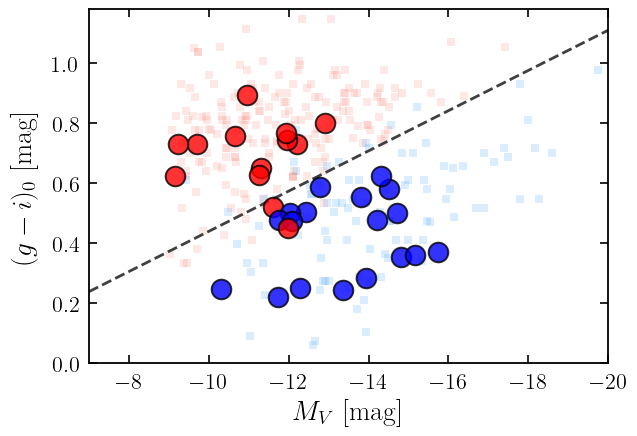

In [23]:
fig, ax = plt.subplots(figsize=(6.7, 4.6))
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D


etg = elves_sat_cat['ETG'] == 'True'
ax.scatter(elves_sat_cat['MVmag'][etg], gi[etg], c='salmon', marker='s', s=30, alpha=0.18, lw=0, zorder=1)
ax.scatter(elves_sat_cat['MVmag'][~etg], gi[~etg], c='dodgerblue', marker='s', s=30, alpha=0.16, lw=0, zorder=1)

_x = np.linspace(-7, -20, 100)
ax.plot(_x, -0.067 * _x - 0.23, ls='--', c='0.25', lw=2, zorder=2)

bounds = np.arange(8, 10.01, 0.25)
cmap = plt.get_cmap('RdYlGn_r', len(bounds) - 1)
# cmap = plt.get_cmap('PuOr_r', len(bounds) - 1)
norm = BoundaryNorm(bounds, cmap.N)

# for obj in temp:
#     ls = '-' if obj['isolated'] else '--'
#     ls = '-'
#     sc = ax.scatter(obj['M_V'], obj['gi_sersic'], c=obj['host_mstar'], cmap=cmap, norm=norm,
#                     s=200, ec='k', marker='o', lw=1.4, ls=ls, alpha=0.8, zorder=5)

for obj in temp:
    if obj['name'] in sf_names:
        c = 'blue'
    else:
        c = 'red'
    sc = ax.scatter(obj['M_V'], obj['gi_sersic'], c=c, 
                    s=200, ec='k', marker='o', lw=1.4, ls=ls, alpha=0.8, zorder=5)

# cbar = fig.colorbar(sc, ax=ax, boundaries=bounds, ticks=bounds, 
#                     spacing='proportional', pad=0.03)
# cbar.set_label(r'$\log\,M_{\star}^{\rm host}/M_\odot$', fontsize=16)
# cbar.ax.tick_params(labelsize=14)

# handles = [
#     Line2D([], [], marker='o', ls='none', ms=13, markerfacecolor='lightgray', markeredgecolor='k', markeredgewidth=1.2, label='ELVES-Dwarf'),
#     Line2D([], [], marker='s', ls='none', ms=8, markerfacecolor='salmon', markeredgecolor='none', alpha=0.45, label='ELVES early-type'),
#     Line2D([], [], marker='s', ls='none', ms=8, markerfacecolor='royalblue', markeredgecolor='none', alpha=0.45, label='ELVES late-type'),
# ]

# ax.legend(handles=handles, loc='upper center', 
#           bbox_to_anchor=(0.48, 1.18), ncol=3, fontsize=16,
#           handletextpad=0., columnspacing=0.5, frameon=False)

ax.set(xlim=(-7, -20), ylim=(0, 1.18), xlabel=r'$M_V$ [mag]', ylabel=r'$(g-i)_0$ [mag]')
ax.xaxis.label.set_size(20); ax.yaxis.label.set_size(20); ax.yaxis.labelpad = 10
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', top=True, right=True, length=6, width=1.2)
ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/sats_color.pdf', dpi=100)

In [33]:
temp[temp['name'] == 'Antlia B']

name,ra,dec,host,host_dist,followup,distance,status,Psat,viz_id,ms_outlier,reff_sersic,m_g_sersic,m_V_sersic,mu_eff_g,mu_0_V,gr_sersic,gi_sersic,n_sersic,ell_sersic,velocity,dist_1sigma,dist_2sigma,dist_SNR,dist_comment,dist_method,ang_proj_kpc,ang_proj_Rvir,err_m_g_sersic,err_gr_sersic,err_m_V_sersic,log_m_star,err_log_m_star,err_reff_sersic,completeness,reference,host_mstar,isolated,M_V
,,,,,,,,,,,arcsec,,,,,,,,,,,,,,,,,,,,,,,,,,,
str14,float64,float64,str10,float64,str9,float64,str12,float64,str24,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,str454,str4,float64,float64,float64,float64,float64,float64,float64,float64,float64,str35,float64,bool,float64
Antlia B,147.2336667,-25.99,NGC3109,1.34,--,1.35,Confirmed,1.0,--,False,42.02264552238806,16.235,15.935523991824038,--,--,0.4994999999999994,0.7322349999999991,--,--,376.0,[1.29 1.41],[1.23 1.47],--,--,TRGB,74.53193185930911,0.7453193185930911,0.4,0.4,0.4,5.8,--,--,1.0,"Sand2015,Doliva-Dolinsky2025",8.161,True,-9.7


In [41]:
temp = master_cat[master_cat['status'] == 'Confirmed']
temp['M_V'] = temp['m_V_sersic'] - (5 * np.log10(temp['host_dist']) + 25)
temp['gr_sersic'][temp['name'] == 'SMC'] = -999.0
temp['gi_sersic'][temp['gi_sersic'].mask] = 1.53 * temp['gr_sersic'][temp['gi_sersic'].mask] - 0.032

print('Only M_V < -9')
temp = temp[temp['M_V'] < -9]
temp = temp[~np.isin(temp['host'], lit_hosts)]
print('Excluding literature hosts')
print('# of sats:', len(temp))
quench_flag = temp['gi_sersic'] > -0.067 * temp['M_V'] - 0.23
print('# of quenched:', np.sum(quench_flag))
print('# of isolated quenched:', np.sum(quench_flag[temp['isolated']]))
print('# of isolated:', np.sum(temp['isolated']))
# temp = temp[temp['M_V'] < -9]

Only M_V < -9
Excluding literature hosts
# of sats: 24
# of quenched: 6
# of isolated quenched: 6
# of isolated: 22


In [42]:
temp = master_cat[master_cat['status'] == 'Confirmed']
temp['M_V'] = temp['m_V_sersic'] - (5 * np.log10(temp['host_dist']) + 25)
temp['gr_sersic'][temp['name'] == 'SMC'] = -999.0
temp['gi_sersic'][temp['gi_sersic'].mask] = 1.53 * temp['gr_sersic'][temp['gi_sersic'].mask] - 0.032

print('Only M_V < -9')
temp = temp[temp['M_V'] < -9]
print('Including literature hosts')
print('# of sats:', len(temp))
quench_flag = temp['gi_sersic'] > -0.067 * temp['M_V'] - 0.23
print('# of quenched:', np.sum(quench_flag))
print('# of isolated quenched:', np.sum(quench_flag[temp['isolated']]))
print('# of isolated:', np.sum(temp['isolated']))


Only M_V < -9
Including literature hosts
# of sats: 34
# of quenched: 13
# of isolated quenched: 8
# of isolated: 24


In [43]:
np.sum(quench_flag) / len(temp)

np.float64(0.38235294117647056)

In [44]:
12/33

0.36363636363636365

In [432]:
temp[quench_flag]['name'].data

array(['Antlia', 'Antlia B', 'SculptorC', 'ESO294-010', 'DDO044',
       'MADCASH-2', 'DDO113', 'dw1301m1627', 'dw0329m4949', 'dw2333m3538',
       'dw0016m2115', 'dw0312m6643', 'dw0317m6614', 'dw1030p2746',
       'dw1245p6158'], dtype='<U14')

In [150]:
np.sum(host_cat['log_mstar_msun'] > 9), np.sum(host_cat['log_mstar_msun'] <= 9)

(np.int64(13), np.int64(26))

In [145]:
np.sum(quench_flag[temp['host_mstar'] > 9]), np.sum(temp['host_mstar'] > 9)

(np.int64(5), np.int64(10))

In [146]:
np.sum(quench_flag[temp['host_mstar'] < 9]), np.sum(temp['host_mstar'] < 9)

(np.int64(7), np.int64(23))

In [24]:
quench_flag1 = temp['gi_sersic'] > -0.067 * temp['M_V'] - 0.23

quench_flag2 = ~np.isin(temp['name'], sf_names)

In [26]:
np.where(quench_flag1 != quench_flag2)

(array([14, 33]),)

## Quenched fraction

Quenched fraction of ELVES-Dwarf satellites vs. stellar mass, compared with the MW+M31 and the ELVES survey (Carlsten et al. 2022).

- **ELVES-Dwarf**: quenched = above the color--$M_V$ cut $(g-i) > -0.067\,M_V - 0.23$ (Carlsten+22). No statistical background subtraction needed (all sats are distance-confirmed), and completeness $\approx 1$ for confirmed sats, so no weighting. Errors are 68\% Jeffreys binomial intervals.
- **MW+M31** and **ELVES** (average of confirmed sats): digitized arrays copied from the `quenched_frac` function in `kuaizi/diezi/scarlet_modeling/script/paper_figure.py`, plotted with the same styles, for consistency with the old figure.

In [45]:
from astropy.stats import binom_conf_interval

def binned_quenched_frac(logms, quenched, bin_edges):
    """Quenched fraction in stellar mass bins, with 68% Jeffreys binomial intervals."""
    cens, fq, fq_lo, fq_hi, ns = [], [], [], [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        m = (logms >= lo) & (logms < hi)
        n, k = np.sum(m), np.sum(quenched & m)
        if n == 0:
            continue
        ci = binom_conf_interval(k, n, confidence_level=0.68, interval='jeffreys')
        cens.append(np.mean(logms[m]))  # mean mass in bin (bins are uneven)
        fq.append(k / n)
        fq_lo.append(ci[0])
        fq_hi.append(ci[1])
        ns.append(n)
    return [np.array(x) for x in (cens, fq, fq_lo, fq_hi, ns)]


########## ELVES-Dwarf ##########
quench_flag = temp['gi_sersic'] > -0.067 * temp['M_V'] - 0.23

# quench_flag = ~np.isin(temp['name'], sf_names)

ed_bins = np.array([5.0, 6.0, 6.6, 7.5, 9.0])
# ed_bins = np.array([5.0, 5.6, 7.0, 7.5, 9.0])
ed_cens, ed_fq, ed_fq_lo, ed_fq_hi, ed_ns = binned_quenched_frac(
    np.asarray(temp['log_m_star']), np.asarray(quench_flag), ed_bins)
print('ELVES-Dwarf N per bin:', ed_ns, ' f_q:', np.round(ed_fq, 2))

ELVES-Dwarf N per bin: [ 5 11 12  6]  f_q: [0.8  0.45 0.33 0.  ]


In [49]:
########## Reference curves, digitized; same arrays as kuaizi/diezi paper_figure.quenched_frac ##########
# MW + M31
MW_M31_q = np.array([5.4949053857350805, 0.9487179487179488,
                     6.496360989810771, 1.,
                     7.491994177583697, 0.832579185520362,
                     8.499272197962156, 0.6666666666666667,
                     9.500727802037847, 0]).reshape(-1, 2)
MW_M31_q_upper = np.array([5.500727802037846, 0.9834087481146305,
                           6.496360989810771, 1.,
                           7.497816593886464, 0.8959276018099548,
                           8.49344978165939, 0.8129713423831071,
                           9.500727802037847, 0.4570135746606335]).reshape(-1, 2)
MW_M31_q_lower = np.array([5.4949053857350805, 0.8506787330316743,
                           6.496360989810771, 0.832579185520362,
                           7.497816593886464, 0.6003016591251886,
                           8.499272197962156, 0.3815987933634992,
                           9.500727802037847, 0]).reshape(-1, 2)

# ELVES average quenched fraction (Carlsten+22, confirmed sats)
elves_confirmed_q = np.array([5.742268041237113, 0.8506024096385543,
                              6.252577319587629, 0.8650602409638555,
                              6.742268041237113, 0.752289156626506,
                              7.247422680412371, 0.6612048192771085,
                              7.747422680412371, 0.7334939759036145,
                              8.24742268041237, 0.392289156626506,
                              8.74742268041237, 0.36337349397590357,
                              9.24742268041237, 0.12626506024096373]).reshape(-1, 2)

elves_confirmed_q_upper = np.array([5.752577319587629, 0.895421686746988,
                                    6.242268041237113, 0.9026506024096386,
                                    6.757731958762887, 0.7956626506024097,
                                    7.247422680412371, 0.7204819277108434,
                                    7.747422680412371, 0.7913253012048194,
                                    8.24742268041237, 0.4949397590361446,
                                    8.74742268041237, 0.5137349397590361,
                                    9.24742268041237, 0.28385542168674693]).reshape(-1, 2)

elves_confirmed_q_lower = np.array([5.752577319587629, 0.7927710843373494,
                                    6.252577319587629, 0.8144578313253013,
                                    6.742268041237113, 0.6959036144578314,
                                    7.247422680412371, 0.5961445783132531,
                                    7.747422680412371, 0.6684337349397591,
                                    8.24742268041237, 0.29831325301204814,
                                    8.74742268041237, 0.23759036144578305,
                                    9.231958762886597, 0.05831325301204815]).reshape(-1, 2)

jahn_2021_q = np.array([
    [4.482253762560524, 1.0000000000000000, 0.8497854077253219, 0.9999999999999999],
    [5.495679371638002, 1.0021459227467810, 0.8497854077253216, 1.0042918454935620],
    [6.509092188329507, 1.0021459227467810, 0.7768240343347640, 1.0042918454935623],
    [7.502638429606698, 0.6695278969957082, 0.4141630901287552, 0.9141630901287552],
    [8.494201851058250, 0.0042918454935622, 0.0042918454935622, 0.2875536480686696],
    [9.465873112323544, 0.0021459227467810, 0.0021459227467810, 0.3497854077253219],
])

elves_field_q = np.array([6.5, 0.3309461121974125,
7.5, 0.15773786528940878,
8.5, 0.,]).reshape(-1, 2)

elves_field_q_lower = np.array([6.5, 0.22627290395050434,
7.5, 0.08484045240316924,
8.5, 0.]).reshape(-1, 2)

elves_field_q_upper = np.array([6.5, 0.45431096477412547,
7.5, 0.2736260601341998,
8.5, 0.11723732147845305]).reshape(-1, 2)

(-0.03, 1.03)

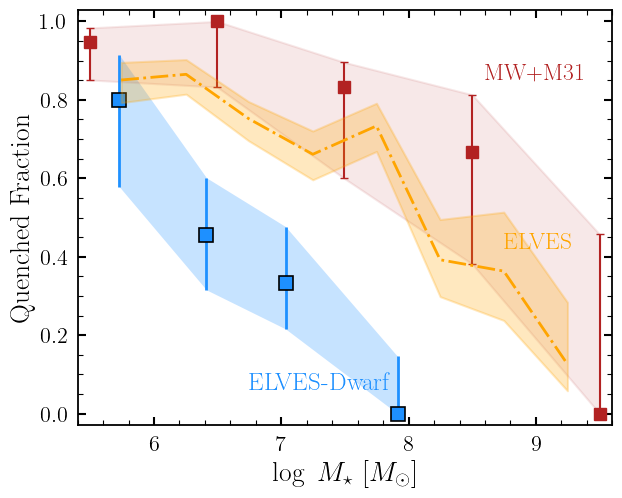

In [50]:
fig, ax = plt.subplots(figsize=(6.9, 5.4))

# ELVES (Carlsten+22 average, confirmed sats)
ax.plot(elves_confirmed_q[:, 0], elves_confirmed_q[:, 1],
        color='orange', ls='-.', lw=2, zorder=12)
ax.fill_between(elves_confirmed_q[:, 0],
                elves_confirmed_q_upper[:, 1], elves_confirmed_q_lower[:, 1],
                facecolor='orange', alpha=0.25, lw=1.5, zorder=12, edgecolor='orange')

###ELVES-Dwarf
ax.errorbar(ed_cens, ed_fq, yerr=[ed_fq - ed_fq_lo, ed_fq_hi - ed_fq],
            fmt='s', color='dodgerblue', mec='k', mew=1.2, ms=10,
            lw=2, capsize=0, zorder=10)
# fmt='s', mfc='firebrick', markersize=8, color='firebrick', zorder=2)
ax.fill_between(ed_cens, ed_fq_lo, ed_fq_hi,
                color='dodgerblue', alpha=0.25, lw=0, zorder=9)

# MW + M31 (same style as paper_figure.quenched_frac with plot_MW_M31=True)
ax.fill_between(MW_M31_q[:, 0], MW_M31_q_upper[:, 1], MW_M31_q_lower[:, 1],
                color='firebrick', alpha=0.1, lw=1.5, zorder=0)
ax.errorbar(MW_M31_q[:, 0], MW_M31_q[:, 1],
            yerr=[-(MW_M31_q_lower[:, 1] - MW_M31_q[:, 1]),
                  (MW_M31_q_upper[:, 1] - MW_M31_q[:, 1])],
            fmt='s', mfc='firebrick', markersize=8, color='firebrick', zorder=2)

# FIRE simulation (Jahn+2021)

# ax.fill_between(jahn_2021_q[:, 0], jahn_2021_q[:, 2], jahn_2021_q[:, 3],
#                 color='#805ea8', alpha=0.1, lw=1.5, zorder=0)
# ax.plot(jahn_2021_q[:, 0], jahn_2021_q[:, 1],
#         color='#805ea8', lw=2.5, zorder=0)

ax.text(8.6, 0.85, 'MW+M31', color='firebrick', fontsize=17)
ax.text(8.75, 0.42, 'ELVES', color='orange', fontsize=17)
ax.text(6.75, 0.06, 'ELVES-Dwarf', color='dodgerblue', fontsize=18)

ax.set_xlabel(r'$\log\ M_\star\ [M_\odot]$', fontsize=20)
ax.set_ylabel(r'Quenched Fraction', fontsize=20)
ax.set_xlim(5.4, 9.6)
ax.set_ylim(0, 1)
ax.set_ylim(-0.03, 1.03)
# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/quenched_frac_demo.pdf', dpi=100, bbox_inches='tight')

In [31]:
elves_confirmed_q

array([[5.74226804, 0.85060241],
       [6.25257732, 0.86506024],
       [6.74226804, 0.75228916],
       [7.24742268, 0.66120482],
       [7.74742268, 0.73349398],
       [8.24742268, 0.39228916],
       [8.74742268, 0.36337349],
       [9.24742268, 0.12626506]])

In [32]:
kuaizi.set_matplotlib(style='JL', usetex=True, figsize=(7, 5), dpi=100, fontsize=17)

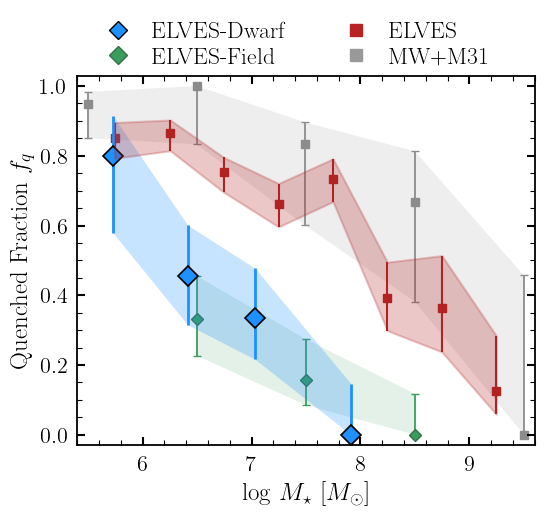

In [89]:
# fig, ax = plt.subplots(figsize=(6.9, 5.4))
fig, ax = plt.subplots(figsize=(5.9, 4.8))

# ELVES (Carlsten+22 average, confirmed sats)
# ax.plot(elves_confirmed_q[:, 0], elves_confirmed_q[:, 1],
        # color='firebrick', ls='-.', lw=2, zorder=12)
ax.fill_between(elves_confirmed_q[:, 0],
                elves_confirmed_q_upper[:, 1], elves_confirmed_q_lower[:, 1],
                facecolor='firebrick', alpha=0.25, lw=1.5, zorder=12, edgecolor='firebrick')
ax.errorbar(elves_confirmed_q[:, 0], elves_confirmed_q[:, 1],
            yerr=[-(elves_confirmed_q_lower[:, 1] - elves_confirmed_q[:, 1]),
                  (elves_confirmed_q_upper[:, 1] - elves_confirmed_q[:, 1])],
            fmt='s', mfc='firebrick', markersize=6, color='firebrick', 
            zorder=2, lw=1.5, capsize=0)

###ELVES-Dwarf
ax.errorbar(ed_cens, ed_fq, yerr=[ed_fq - ed_fq_lo, ed_fq_hi - ed_fq],
            fmt='D', color='dodgerblue', mec='k', mew=1.2, ms=10,
            lw=2, capsize=0, zorder=10)
# fmt='s', mfc='firebrick', markersize=8, color='firebrick', zorder=2)
ax.fill_between(ed_cens, ed_fq_lo, ed_fq_hi,
                color='dodgerblue', alpha=0.25, lw=0, zorder=9)

# MW + M31 (same style as paper_figure.quenched_frac with plot_MW_M31=True)
mw_color = '0.55'
ax.fill_between(MW_M31_q[:, 0], MW_M31_q_upper[:, 1], MW_M31_q_lower[:, 1],
                color=mw_color, alpha=0.14, lw=1, zorder=0, edgecolor=None)
ax.errorbar(MW_M31_q[:, 0], MW_M31_q[:, 1],
            yerr=[-(MW_M31_q_lower[:, 1] - MW_M31_q[:, 1]),
                  (MW_M31_q_upper[:, 1] - MW_M31_q[:, 1])],
            fmt='s', mfc=mw_color, markersize=6, color=mw_color, zorder=1,
           elinewidth=1.3,)

# ELVES-Field
ef_color = '#53b330'
ef_color = "#3A9D5D"
ax.fill_between(elves_field_q[:, 0], elves_field_q_upper[:, 1], elves_field_q_lower[:, 1],
                color=ef_color, alpha=0.14, lw=1, zorder=0, edgecolor=None)
ax.errorbar(elves_field_q[:, 0], elves_field_q[:, 1],
            yerr=[-(elves_field_q_lower[:, 1] - elves_field_q[:, 1]),
                  (elves_field_q_upper[:, 1] - elves_field_q[:, 1])],
            fmt='D', mfc=ef_color, mec='#357048', markersize=6, color=ef_color, zorder=1,
            elinewidth=1.3,)

# FIRE simulation (Jahn+2021)

# ax.fill_between(jahn_2021_q[:, 0], jahn_2021_q[:, 2], jahn_2021_q[:, 3],
#                 color='#805ea8', alpha=0.1, lw=1.5, zorder=0)
# ax.plot(jahn_2021_q[:, 0], jahn_2021_q[:, 1],
#         color='#805ea8', lw=2.5, zorder=0)

# ax.text(8.6, 0.85, 'MW+M31', color='orange', fontsize=17)
# ax.text(8.75, 0.42, 'ELVES', color='firebrick', fontsize=17)
# ax.text(6.75, 0.06, 'ELVES-Dwarf', color='dodgerblue', fontsize=18)

from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker='D', ls='', mfc='#1e90ff', mec='k', ms=9, label='ELVES-Dwarf'),
    Line2D([], [], marker='D', ls='', mfc=ef_color, mec='#357048', ms=9, label='ELVES-Field'),
    Line2D([], [], marker='s', ls='', color='#b82323', ms=8, label='ELVES'),
    Line2D([], [], marker='s', ls='', color='0.6', ms=9, label='MW+M31'),
]

# ax.legend(handles=handles, frameon=False, loc='upper center',
#           fontsize=17, handletextpad=0.0, labelspacing=0.1, 
#           # columnspacing=1.2,
#           columnspacing=0.2,
#           ncols=4, bbox_to_anchor=(0.47, 1.16))

ax.legend(handles=handles, frameon=False, loc='upper center',
          fontsize=17, handletextpad=0.4, labelspacing=0.2, 
          # columnspacing=1.2,
          columnspacing=2.0,
          ncols=2, bbox_to_anchor=(0.47, 1.23))

ax.set_xlabel(r'$\log\,M_\star\ [M_\odot]$', fontsize=18)
ax.set_ylabel(r'Quenched Fraction $f_q$', fontsize=18)
ax.set_xlim(5.4, 9.6)
ax.set_ylim(0, 1)
ax.set_ylim(-0.03, 1.03)

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/quenched_frac.pdf', 
            dpi=100, bbox_inches='tight')

In [154]:
def moving_binned_statistic(x, values, x_err=None, statistic='mean', bins=10, range_=None, n_slide=20):
    range_0 = range_
    edges_0 = np.histogram_bin_edges(x, bins=bins, range=range_0)
    delta_x = np.diff(edges_0)[0] / n_slide

    output = np.zeros((n_slide, bins))
    cens = np.zeros((n_slide, bins))  # centers
    for k in np.arange(n_slide):
        i = k - n_slide // 2
        _range = range_0 + i * delta_x
        cens[k] = 0.5 * (edges_0[:-1] + edges_0[1:]) + i * delta_x
        if x_err is None:
            output[k] = binned_statistic(
                x, values, statistic=statistic, bins=bins, range=_range).statistic
        else:
            _x = np.log10(np.abs(10**x + np.random.normal(loc=0, scale=x_err)))
            output[k] = binned_statistic(
                _x, values, statistic=statistic, bins=bins, range=_range).statistic

    return output, cens[len(cens) // 2]

In [155]:
########## ELVES-Dwarf quenched fraction with sliding bins (as in paper_figure.quenched_frac) ##########
from scipy.stats import binned_statistic  # needed by moving_binned_statistic

logms = np.asarray(temp['log_m_star'])
err_dex = np.asarray(temp['err_log_m_star'])
err_dex = np.where(np.isfinite(err_dex), err_dex, np.nanmedian(err_dex))  # lit sats have no mass error
# moving_binned_statistic perturbs in *linear* mass, so convert the dex error to linear
x_err_lin = np.log(10) * err_dex * 10**logms

np.random.seed(42)
mb_bins, mb_range = 6, np.array([5.5, 9.1])
y1, mb_cens = moving_binned_statistic(logms, quench_flag.astype(float), x_err=x_err_lin,
                                      statistic='sum', range_=mb_range, bins=mb_bins, n_slide=20)
y2, mb_cens = moving_binned_statistic(logms, np.ones_like(logms), x_err=x_err_lin,
                                      statistic='sum', range_=mb_range, bins=mb_bins, n_slide=20)

mb_num = np.median(y2, axis=0)
with np.errstate(invalid='ignore', divide='ignore'):
    mb_fq = np.nanmedian(y1 / y2, axis=0)
    mb_fq_std = np.nanstd(y1 / y2, axis=0)

# drop poorly populated bins (only ~1 sat above logM* ~ 8)
mb_fq[mb_num < 3] = np.nan
mb_fq_std[mb_num < 3] = np.nan

print('centers:', np.round(mb_cens, 2))
print('N per bin:', mb_num)
print('f_q:', np.round(mb_fq, 2))
print('std:', np.round(mb_fq_std, 2))

centers: [5.8 6.4 7.  7.6 8.2 8.8]
N per bin: [ 6.  11.5  6.5  7.   1.   1. ]
f_q: [0.8  0.45 0.33 0.12  nan  nan]
std: [0.21 0.09 0.06 0.1   nan  nan]


(0.0, 1.05)

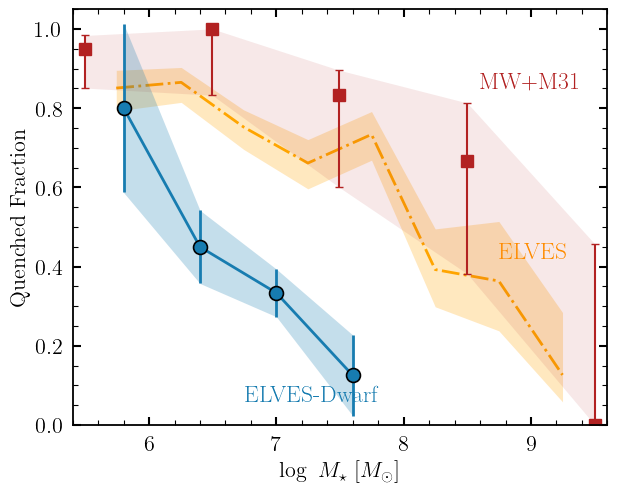

In [156]:
fig, ax = plt.subplots(figsize=(6.9, 5.4))

# ELVES (Carlsten+22 average, confirmed sats)
ax.plot(elves_confirmed_q[:, 0], elves_confirmed_q[:, 1],
        color='orange', ls='-.', lw=2, zorder=1)
ax.fill_between(elves_confirmed_q[:, 0],
                elves_confirmed_q_upper[:, 1], elves_confirmed_q_lower[:, 1],
                color='orange', alpha=0.25, lw=0, zorder=1)

# MW + M31 (same style as paper_figure.quenched_frac with plot_MW_M31=True)
ax.fill_between(MW_M31_q[:, 0], MW_M31_q_upper[:, 1], MW_M31_q_lower[:, 1],
                color='firebrick', alpha=0.1, lw=0, zorder=2)
ax.errorbar(MW_M31_q[:, 0], MW_M31_q[:, 1],
            yerr=[-(MW_M31_q_lower[:, 1] - MW_M31_q[:, 1]),
                  (MW_M31_q_upper[:, 1] - MW_M31_q[:, 1])],
            fmt='s', mfc='firebrick', markersize=8, color='firebrick', zorder=2)

# ELVES-Dwarf, sliding bins
good = np.isfinite(mb_fq)
ax.errorbar(mb_cens[good], mb_fq[good], yerr=mb_fq_std[good],
            fmt='o-', color='#177cb0', mfc='#177cb0', mec='k', mew=1.2, ms=10,
            lw=2, capsize=0, zorder=10)
ax.fill_between(mb_cens[good], (mb_fq - mb_fq_std)[good], (mb_fq + mb_fq_std)[good],
                color='#177cb0', alpha=0.25, lw=0, zorder=9)

ax.text(8.6, 0.85, 'MW+M31', color='firebrick', fontsize=17)
ax.text(8.75, 0.42, 'ELVES', color='darkorange', fontsize=17)
ax.text(6.75, 0.06, 'ELVES-Dwarf', color='#177cb0', fontsize=17)

ax.set_xlabel(r'$\log\ M_\star\ [M_\odot]$')
ax.set_ylabel(r'Quenched Fraction')
ax.set_xlim(5.4, 9.6)
ax.set_ylim(0, 1.05)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/quenched_frac_moving.pdf', dpi=100, bbox_inches='tight')

In [201]:
########## Split by host stellar mass (same fixed bins + Jeffreys errors as the fiducial figure) ##########
lo_host = np.asarray(temp['host_mstar'] <= 8.8)

lo_cens, lo_fq, lo_fq_lo, lo_fq_hi, lo_ns = binned_quenched_frac(
    np.asarray(temp['log_m_star'])[lo_host], np.asarray(quench_flag)[lo_host], ed_bins)
hi_cens, hi_fq, hi_fq_lo, hi_fq_hi, hi_ns = binned_quenched_frac(
    np.asarray(temp['log_m_star'])[~lo_host], np.asarray(quench_flag)[~lo_host], ed_bins)

print(f'Host logM* <= 9: {np.sum(lo_host)} sats, N per bin: {lo_ns}, f_q: {np.round(lo_fq, 2)}')
print(f'Host logM* >  9: {np.sum(~lo_host)} sats, N per bin: {hi_ns}, f_q: {np.round(hi_fq, 2)}')

Host logM* <= 9: 18 sats, N per bin: [4 7 5 2], f_q: [0.75 0.29 0.2  0.  ]
Host logM* >  9: 20 sats, N per bin: [6 4 6 4], f_q: [1.   0.75 0.33 0.  ]


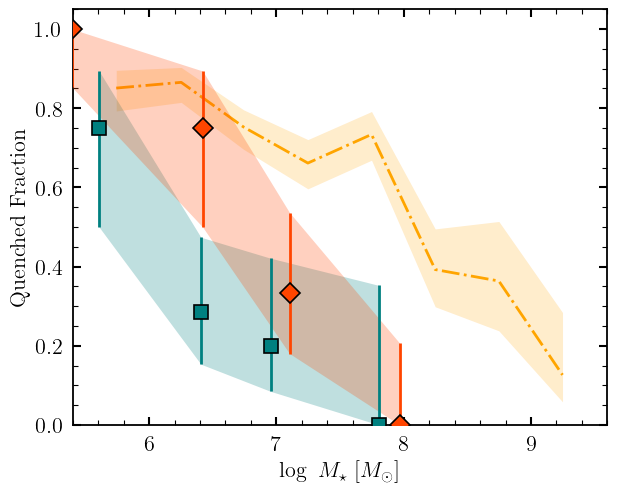

In [202]:
fig, ax = plt.subplots(figsize=(6.9, 5.4))

# ELVES (Carlsten+22 average, confirmed sats)
ax.plot(elves_confirmed_q[:, 0], elves_confirmed_q[:, 1],
        color='orange', ls='-.', lw=2, zorder=1)
ax.fill_between(elves_confirmed_q[:, 0],
                elves_confirmed_q_upper[:, 1], elves_confirmed_q_lower[:, 1],
                color='orange', alpha=0.2, lw=0, zorder=1)

# ELVES-Dwarf, split by host stellar mass
ax.errorbar(lo_cens, lo_fq, yerr=[lo_fq - lo_fq_lo, lo_fq_hi - lo_fq], 
            fmt='s', color='teal', mec='k', mew=1.2, ms=10,
            lw=2, capsize=0, zorder=10)
ax.fill_between(lo_cens, lo_fq_lo, lo_fq_hi,
                color='teal', alpha=0.25, lw=0, zorder=9)


ax.errorbar(hi_cens, hi_fq, yerr=[hi_fq - hi_fq_lo, hi_fq_hi - hi_fq], 
            fmt='D', color='orangered', mec='k', mew=1.2, ms=10,
            lw=2, capsize=0, zorder=10)
ax.fill_between(hi_cens, hi_fq_lo, hi_fq_hi,
                color='orangered', alpha=0.25, lw=0, zorder=9)

# handles = [
#     Line2D([], [], marker='o', ls='-', lw=2, color='#177cb0', mfc='#177cb0', mec='k', mew=1.2, ms=10,
#            label=r'Host $\log M_\star \leq 9$'),
#     Line2D([], [], marker='D', ls='--', lw=2, color='#057748', mfc='#057748', mec='k', mew=1.2, ms=9,
#            label=r'Host $\log M_\star > 9$'),
# ]
# ax.legend(handles=handles, loc='lower left', fontsize=15, frameon=False,
#           labelspacing=0.3, handletextpad=0.5)

ax.set_xlabel(r'$\log\ M_\star\ [M_\odot]$')
ax.set_ylabel(r'Quenched Fraction')
ax.set_xlim(5.4, 9.6)
ax.set_ylim(0, 1.05)

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/paper2/quenched_frac_host_mass.pdf', dpi=100, bbox_inches='tight')

In [69]:
hscla_hosts[6]

'DDO046'

In [70]:
hosts[7]

'NGC4625'

In [72]:
np.mean([sat_cats[i]['gr_sersic'].mean() for i in range(len(hosts))])

0.39861111111111114

In [73]:
sat_cats[0]

name,ra,dec,host,host_dist,followup,distance,status,Psat,viz_id,ms_outlier,reff_sersic,m_g_sersic,m_V_sersic,mu_eff_g,mu_0_V,gr_sersic,gi_sersic,n_sersic,ell_sersic,velocity,dist_1sigma,dist_2sigma,dist_SNR,dist_comment,ang_proj,ang_proj_Rvir,err_m_g_sersic,err_gr_sersic,err_m_V_sersic,log_m_star,err_log_m_star,err_reff_sersic,completeness
,,,,,,,,,,,,,,,,,,,,,,,,,deg,,,,,,,,
bytes11,float64,float64,bytes7,float64,bytes6,float64,bytes8,float64,bytes23,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,bytes24,float64,float64,float64,float64,float64,float64,float64,float64,float64
dw1327p5141,201.75545,51.68591,NGC5238,4.51,HSC-LA,20.694,Rejected,0.0,2019p517_201.755_51.686,False,7.734,19.082,18.872,25.519,24.643,0.392,--,0.717,0.328,--,[14.535 inf],[11.609 inf],1.035,"very smooth, with an NSC",1.1948584497450983,1.2883904840466507,0.11215384615384619,0.04685911449956982,0.11457499447969242,5.608,0.091,0.7184728163265308,1.0
dw1336p5108,204.03102,51.14638,NGC5238,4.51,HSC-LA,20.082,Rejected,0.0,2040p512_204.031_51.146,False,6.932,19.074,18.741,25.274,24.087,0.642,--,0.836,0.375,--,[12.854 inf],[9.566 inf],0.772,very smooth and tiny,0.5172530786690424,0.5577430067496258,0.11200000000000006,0.04679619636869793,0.11441796624064093,6.055,0.091,0.6428368979591841,1.0
